# **Text Mining Project 2025/26**

1. ✅ Data Exploration        ← já fizemos
2. 🔄 Data Preprocessing     ← próximo passo
3.    Corpus Split            ← train/validation
4.    Feature Engineering     ← BoW, Word2Vec, Transformers
5.    Classification Models   ← ML clássico + Transformers
6.    Avaliação & Análise     ← métricas e conclusões
7.    Predições no test.csv   ← ficheiro pred_xx.csv final 

<b><h3> Group 40</h3></b>

<table>
  <thead style="color:#d9c8a3;">
    <tr>
      <th>Name</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Rodrigo Santos</td>
      <td>20250387</td>
    </tr>
    <tr>
      <td>Mónica Shaskin</td>
      <td>20250392</td>
    </tr>
    <tr>
      <td>Nadia Scaletchi</td>
      <td>20250404</td>
    </tr>
    <tr>
      <td>Rodrigo Teixeira</td>
      <td>20250393</td>
    </tr>
  </tbody>
</table> 

## **Table of Contents**

# **1. Introduction**

# **2. Enviroment Setup and Data Loading**

### **Library Installation**

In [2]:
!pip install nltk
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Imports**

In [3]:
# Standard Libraries
import re
import string
import warnings
from collections import Counter
from itertools import combinations

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

### **Settings and NLP Resources**

In [4]:
warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

STOP = set(stopwords.words("english"))

### **Class Labels and Visualization Colors**

In [5]:
# Palette consistent with the three classes
CLASS_COLORS = {
    0: "#e74c3c",
    1: "#2ecc71",
    2: "#3498db"
}

CLASS_NAMES = {
    0: "Bearish (0)",
    1: "Bullish (1)",
    2: "Neutral (2)"
}

### **Load Training Dataset**

In [6]:
df = pd.read_csv('train.csv')  

# **3. Exploratory Data Analysis**

This section explores the structure and main characteristics of the training corpus before applying preprocessing and modelling techniques.

## **3.1 Dataset Overview and Duplicate Analysis**

### **Dataset Overview**

This first step provides a general overview of the dataset, including its dimensions, variables, data types, missing values, and initial observations.

In [7]:
# Print the dimensions of the DataFrame (rows, columns)
print(f'Shape: {df.shape}')

# Print the list of column names
print(f'Columns: {list(df.columns)}')

# Print the data type of each column
print(f'Types:\n{df.dtypes}')

# Print the count of missing (NaN) values per column
print(f'\nMissing values:\n{df.isnull().sum()}')

# Display the first 10 rows of the DataFrame
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']
Types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


### **Duplicate Analysis**

This step checks whether the training dataset contains duplicated tweets or tweets that appear multiple times with different sentiment labels.

In [8]:
# Count rows with duplicate text (regardless of label)
exact_duplicates = df.duplicated(subset='text').sum()
# Count rows with duplicate text AND label
label_duplicates = df.duplicated(subset=['text', 'label']).sum()

print(f'Duplicate tweets (same text): {exact_duplicates}')
print(f'Duplicate tweets (same text + label): {label_duplicates}')

# Show duplicate examples if any exist
if exact_duplicates > 0:
    mask = df.duplicated(subset='text', keep=False)
    print(f'\nDuplicate tweet examples:')
    print(df[mask][['text','label']].sort_values('text').head(10).to_string())
    
    # Edge case: same tweet with conflicting labels — dangerous for training!
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]  # Keep only texts with more than one distinct label
    print(f'\nTweets with conflicting labels (same text, different label): {len(conflicts)}')
    if len(conflicts) > 0:
        # Show the conflicting rows
        print(df[df['text'].isin(conflicts.index)][['text','label']].sort_values('text').head(10).to_string())

Duplicate tweets (same text): 0
Duplicate tweets (same text + label): 0


**Dataset Overview and Duplicate Analysis - Conclusion:**

- **Dataset structure:**  
  The training dataset contains 9543 tweets and 2 columns: `text` and `label`. The `text` column contains the tweet content, while the `label` column contains the sentiment class assigned to each tweet.

- **Data types:**  
  The data types are appropriate for this classification task. The `text` column is stored as an object/string variable, and the `label` column is stored as an integer, which is suitable for representing the sentiment classes.

- **Missing values:**  
  No missing values were found in either column. This means that no tweets need to be removed or imputed due to missing text or labels.

- **Duplicate records:**  
  No duplicated tweets were found in the dataset. There were also no duplicated rows with the same text and label. Therefore, there is no evidence of repeated tweets or conflicting duplicated labels in the training data.

  Overall, the dataset is clean and structurally suitable for the next stages of the project. The main variables are available, the data types are correct, and no missing or duplicated records were detected.

## **3.2 Class Distribution**

This analysis examines the distribution of the three sentiment classes and helps identify possible class imbalance in the dataset. 

=== Class count ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


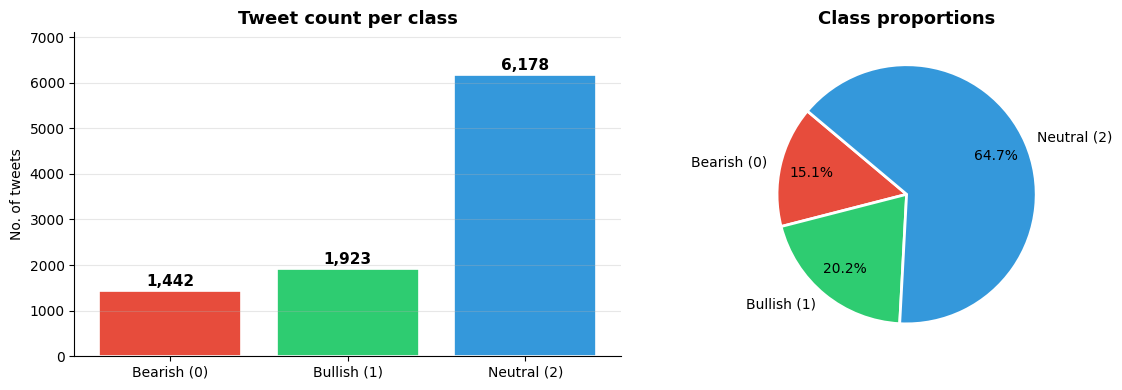


Baseline (majority class): 64.7% — any model should beat this value.


In [44]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== Class count ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — count per class with value labels on top
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No. of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart — class proportions
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Majority class baseline: accuracy of a model that always predicts the most frequent class.
# Any trained model must beat this, otherwise it has learned nothing useful.
majority_acc = label_counts.max() / len(df) * 100
print(f'\nBaseline (majority class): {majority_acc:.1f}% — any model should beat this value.')

**Class Distribution - Conclusion:**

- **Imbalanced dataset:**  
  The class distribution shows a clear imbalance in the training data. Neutral tweets represent the majority class, with 6178 tweets (64.7%), while Bullish tweets account for 1923 tweets (20.2%) and Bearish tweets for only 1442 tweets (15.1%).

- **Majority class baseline:**  
  Since the Neutral class represents 64.7% of the dataset, a simple model that always predicts Neutral would already achieve 64.7% accuracy. Therefore, accuracy alone may be misleading, as it could hide poor performance on the minority classes.

- **Impact on model evaluation and metric choice:**  
  Because Bearish and Bullish tweets are less represented, models may become biased toward the Neutral class if the imbalance is not considered. For this reason, Macro F1-score will be used as an important evaluation metric in the modelling stage. Unlike accuracy, Macro F1-score gives equal importance to each class, making it more appropriate for evaluating performance in an imbalanced multi-class classification problem.

## **3.3 Tweet Lenght Analysis**

This section analyzes whether tweet length varies across sentiment classes, using both word count and character count. This helps assess whether length-related patterns may provide useful information for later classification.

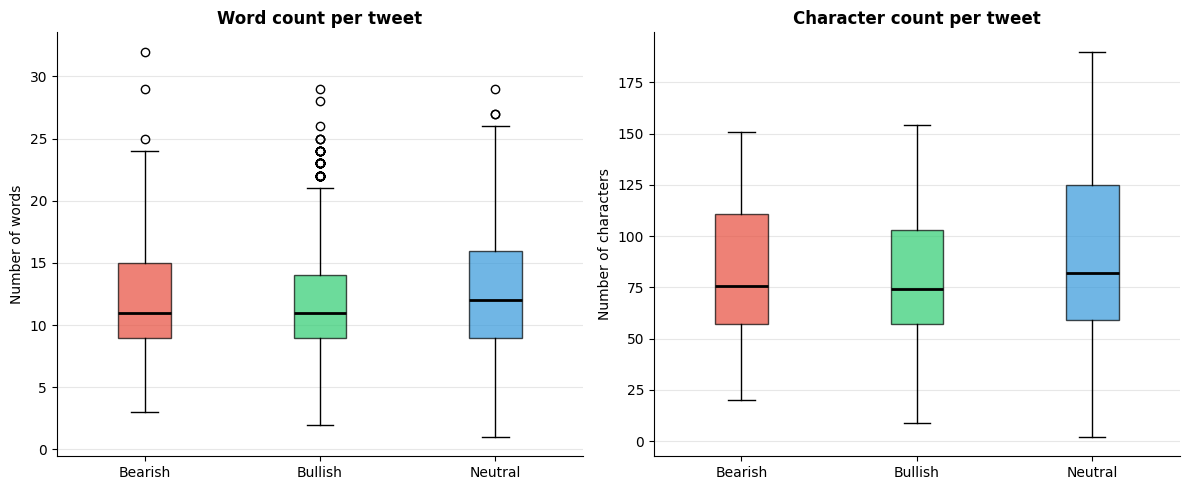

Kruskal-Wallis p-value for word count: 0.0113
Kruskal-Wallis p-value for character count: 0.0000000000000014

Average length per class:
             n_words  n_chars
label                        
Bearish (0)     12.0     83.4
Bullish (1)     11.9     80.4
Neutral (2)     12.3     88.1


In [46]:
from scipy import stats

# Compute length features for each tweet
df["n_words"] = df["text"].str.split().str.len()
df["n_chars"] = df["text"].str.len()

# Boxplots by sentiment class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for metric, ax, title, ylabel in [
    ("n_words", axes[0], "Word count per tweet", "Number of words"),
    ("n_chars", axes[1], "Character count per tweet", "Number of characters")
]:
    data = [
        df[df["label"] == lbl][metric].values
        for lbl in [0, 1, 2]
    ]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2}
    )

    for patch, lbl in zip(bp["boxes"], [0, 1, 2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)

    ax.set_xticklabels(["Bearish", "Bullish", "Neutral"], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Kruskal-Wallis tests for length differences across classes
word_groups = [
    df[df["label"] == lbl]["n_words"]
    for lbl in [0, 1, 2]
]

char_groups = [
    df[df["label"] == lbl]["n_chars"]
    for lbl in [0, 1, 2]
]

stat_words, p_words = stats.kruskal(*word_groups)
stat_chars, p_chars = stats.kruskal(*char_groups)

print(f"Kruskal-Wallis p-value for word count: {p_words:.4f}")
print(f"Kruskal-Wallis p-value for character count: {p_chars:.16f}")

# Average length by class
print("\nAverage length per class:")
print(
    df.groupby("label")[["n_words", "n_chars"]]
    .mean()
    .round(1)
    .rename(index=CLASS_NAMES)
)

**Tweet Length Analysis - Conclusions:**

- The boxplots show that tweet length is generally similar across the three sentiment classes. However, Neutral tweets appear slightly longer, especially in terms of character count, and also show a wider range of values.

- Some outliers are present in all classes, particularly in the word count distribution. These correspond to tweets that are longer than most observations in the same class, which is expected in social media data where tweet length can vary considerably.

- To complement the visual analysis, the Kruskal-Wallis test was applied. This non-parametric test evaluates whether the distributions of tweet length are statistically different across the three sentiment classes.

- The hypotheses tested are:
  - H₀: Bearish, Bullish, and Neutral tweets have the same length distribution.
  - H₁: At least one sentiment class has a different length distribution.

- The test results show statistically significant differences for both word count and character count. This supports what is suggested by the boxplots: the classes are not exactly identical in terms of tweet length.

- The difference is stronger for character count, where the p-value is extremely small. This is consistent with the class averages, since Neutral tweets have the highest average number of characters, followed by Bearish and then Bullish tweets.

- However, the average word counts are very close across classes: Bearish tweets have 12.0 words on average, Bullish tweets have 11.9, and Neutral tweets have 12.3. Therefore, although the Kruskal-Wallis test detects statistically significant differences, the practical difference in word count is small.

## **3.4 Vocabulary Analysis and Word Clouds**

This section explores the most frequent words in the corpus after a simple exploratory text-cleaning process. For this analysis, tweets were lowercased and filtered to remove URLs, mentions, hashtags, punctuation, numbers, stopwords, and very short tokens. This helps reduce noise and makes the most informative words more visible in the frequency rankings.

First, the top 25 most frequent words in the full corpus are visualized to provide an overview of the dominant vocabulary without making the chart too crowded. Then, the same cleaning function is applied separately to each sentiment class to compare vocabulary patterns across Bearish, Bullish, and Neutral tweets.

Since the classes may have different sizes, class-specific word frequencies are presented as relative frequency per 1000 words instead of raw counts. This allows a fairer comparison and helps identify which terms are more characteristic of each sentiment class.

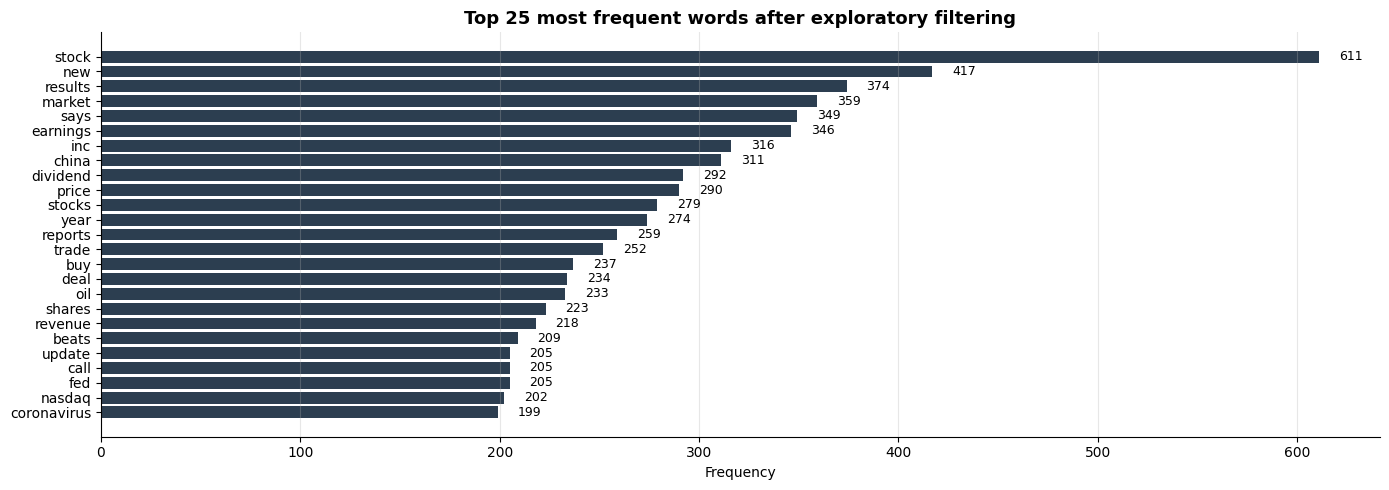

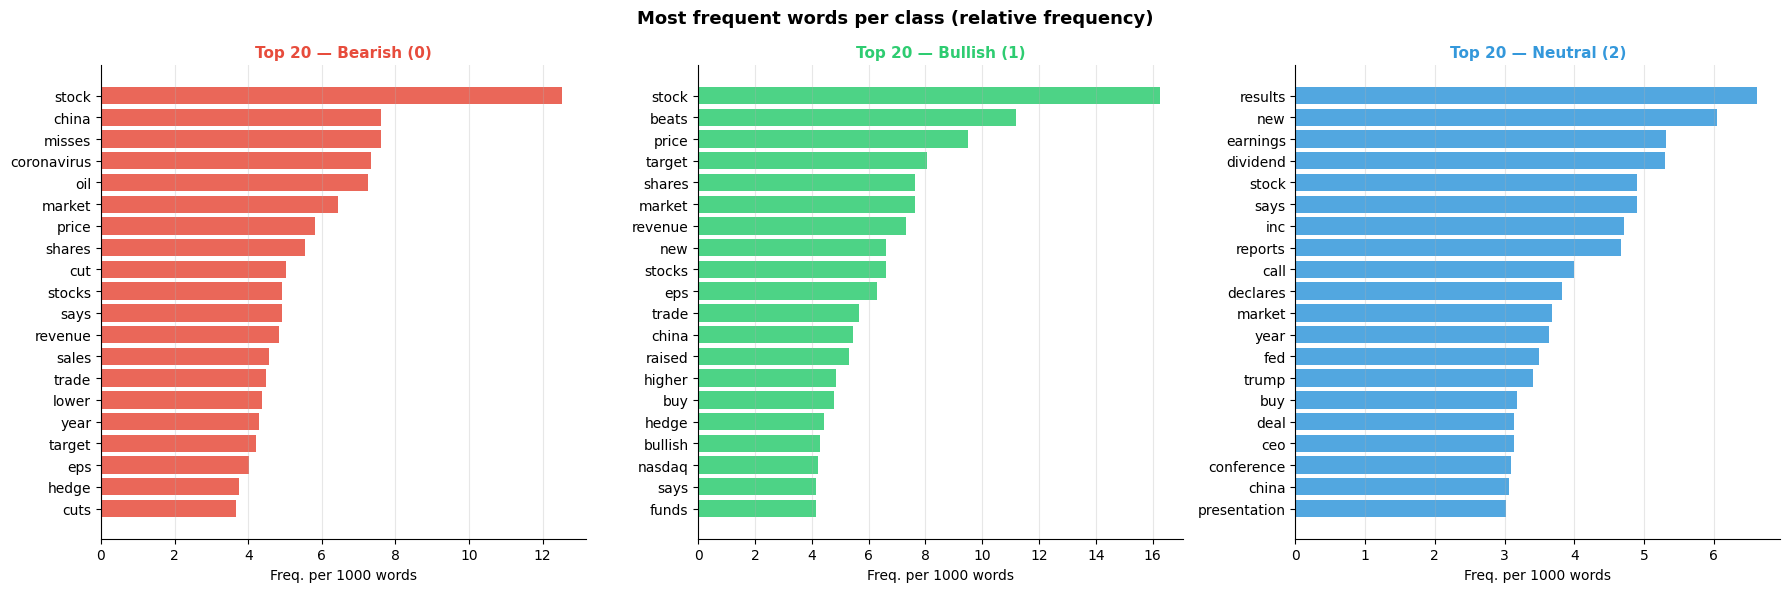

In [47]:
# ── tokenize_clean: strip URLs, mentions, hashtags, punctuation and stopwords ─

def tokenize_clean(text):
    """Tokenizes, lowercases, removes punctuation, URLs, mentions, hashtags and stopwords."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)            # remove @mentions and #hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]


# ── Overall vocabulary ────────────────────────────────────────────────────────

# Build a flat list of all tokens across every tweet
all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_clean(txt))

# Calculate word frequencies
freq  = Counter(all_tokens)
top50 = freq.most_common(50)

# Horizontal bar chart — top 25 most frequent words
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')

# Add frequency labels at the end of each bar
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', fontsize=9)

ax.set_title('Top 25 most frequent words after exploratory filtering',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


# ── Most frequent words by sentiment class ────────────────────────────────────

# Build a token counter for each sentiment class
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_clean(txt))
    tokens_per_class[lbl] = Counter(toks)

# Total token count per class (used to normalise frequencies)
total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Relative frequency per 1000 words (only words appearing at least 5 times)
    rel_freq = {w: cnt / total_per_class[lbl] * 1000
                for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]

    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Most frequent words per class (relative frequency)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

We also generated word clouds for each sentiment class to provide a visual complement to the previous vocabulary analysis.

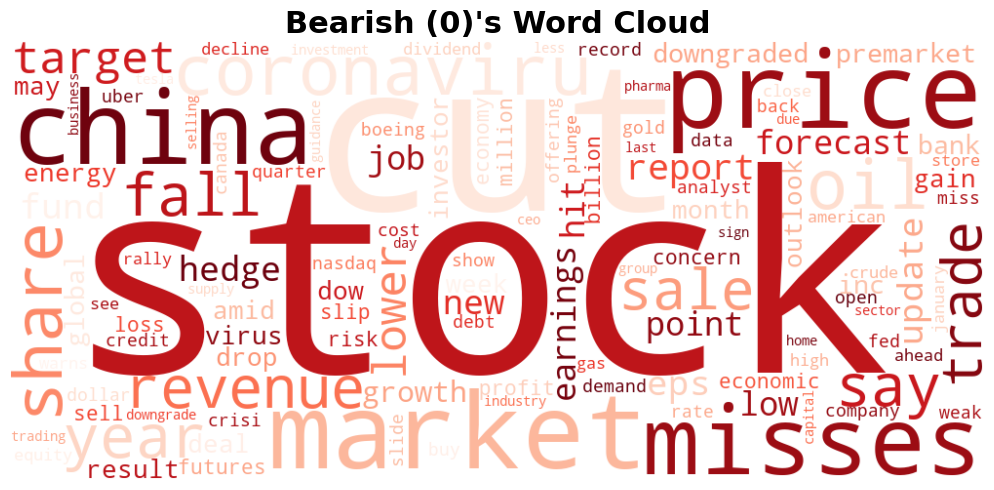

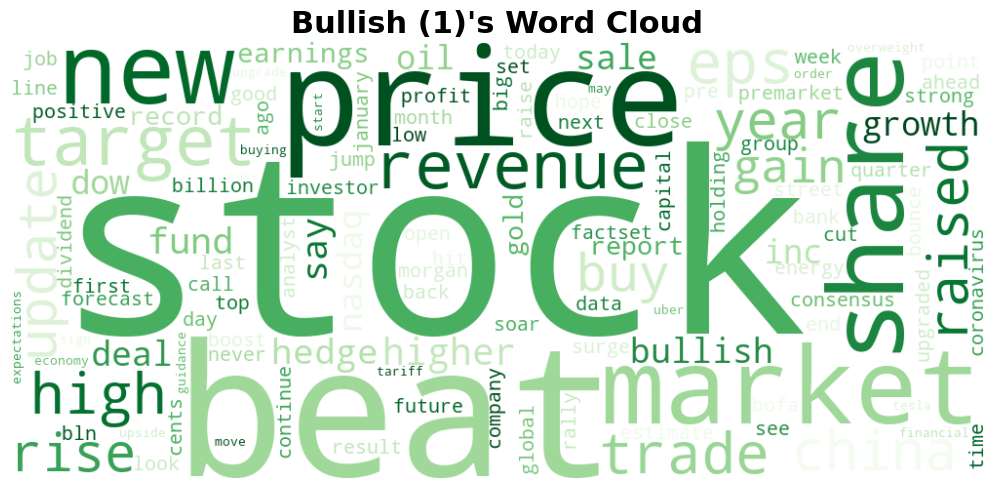

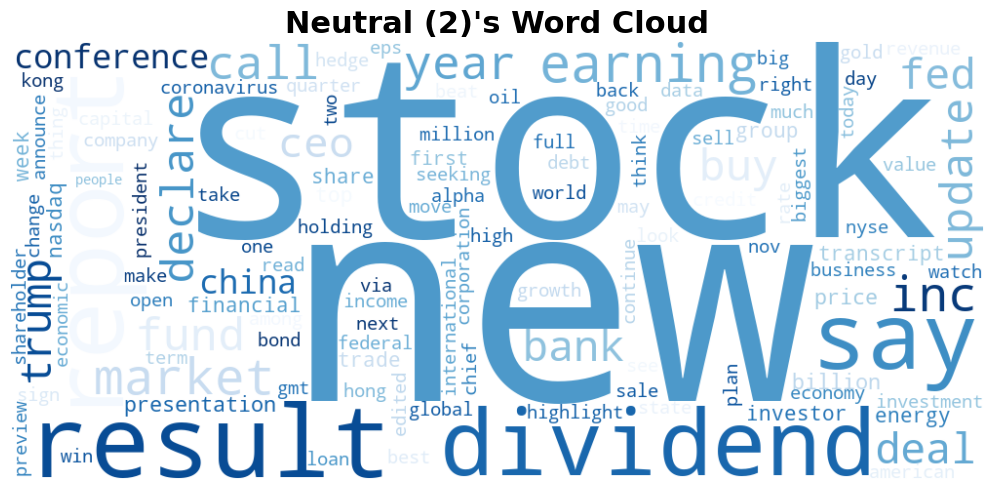

In [48]:
# Create one large word cloud per class
for lbl in [0, 1, 2]:
    class_tokens = []
    
    for txt in df[df["label"] == lbl]["text"]:
        class_tokens.extend(tokenize_clean(txt))
    
    text_for_cloud = " ".join(class_tokens)
    
    wordcloud = WordCloud(
        width=1000,
        height=450,
        background_color="white",
        colormap="Greens" if lbl == 1 else "Reds" if lbl == 0 else "Blues",
        collocations=False,
        max_words=120
    ).generate(text_for_cloud)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{CLASS_NAMES[lbl]}'s Word Cloud", fontsize=22, fontweight="bold")
    plt.tight_layout()
    plt.show()

**Vocabulary Analysis and Word Clouds - Conclusion:**

- **Common financial vocabulary:**  
  The vocabulary analysis shows that all three sentiment classes share a common financial lexicon, with frequent terms such as *stock*, *market*, *price*, *earnings*, and *trade*. This confirms that the dataset is strongly centered on financial and market-related topics.

- **Bearish vocabulary patterns:**  
  Bearish tweets contain more negative or downward-oriented terms, such as *misses*, *cut*, *lower*, and *revenue*. These words are consistent with weaker company performance, negative expectations, or downward market movements.

- **Bullish vocabulary patterns:**  
  Bullish tweets are more associated with positive performance and analyst-related language, including terms such as *beats*, *target*, *raised*, *higher*, and *bullish*. This suggests that Bullish tweets often refer to positive expectations, upgrades, or better-than-expected results.

- **Neutral vocabulary patterns:**  
  Neutral tweets are dominated by factual and reporting-oriented words, such as *results*, *earnings*, *dividend*, *reports*, *declares*, *call*, and *conference*. This suggests that Neutral tweets often contain financial information without expressing a clear positive or negative market direction.

- **Implications for modelling:**  
  Overall, these results suggest that vocabulary patterns contain useful sentiment information. This supports the use of text-based feature extraction methods in the modelling stage, since relevant sentiment cues appear across the lexical patterns of each class.

## **3.5 Exclusive Words by Sentiment Class**

This analysis identifies words that appear only within one sentiment class after exploratory text processing. Although these terms should be interpreted carefully, they can provide additional insight into class-specific vocabulary patterns.

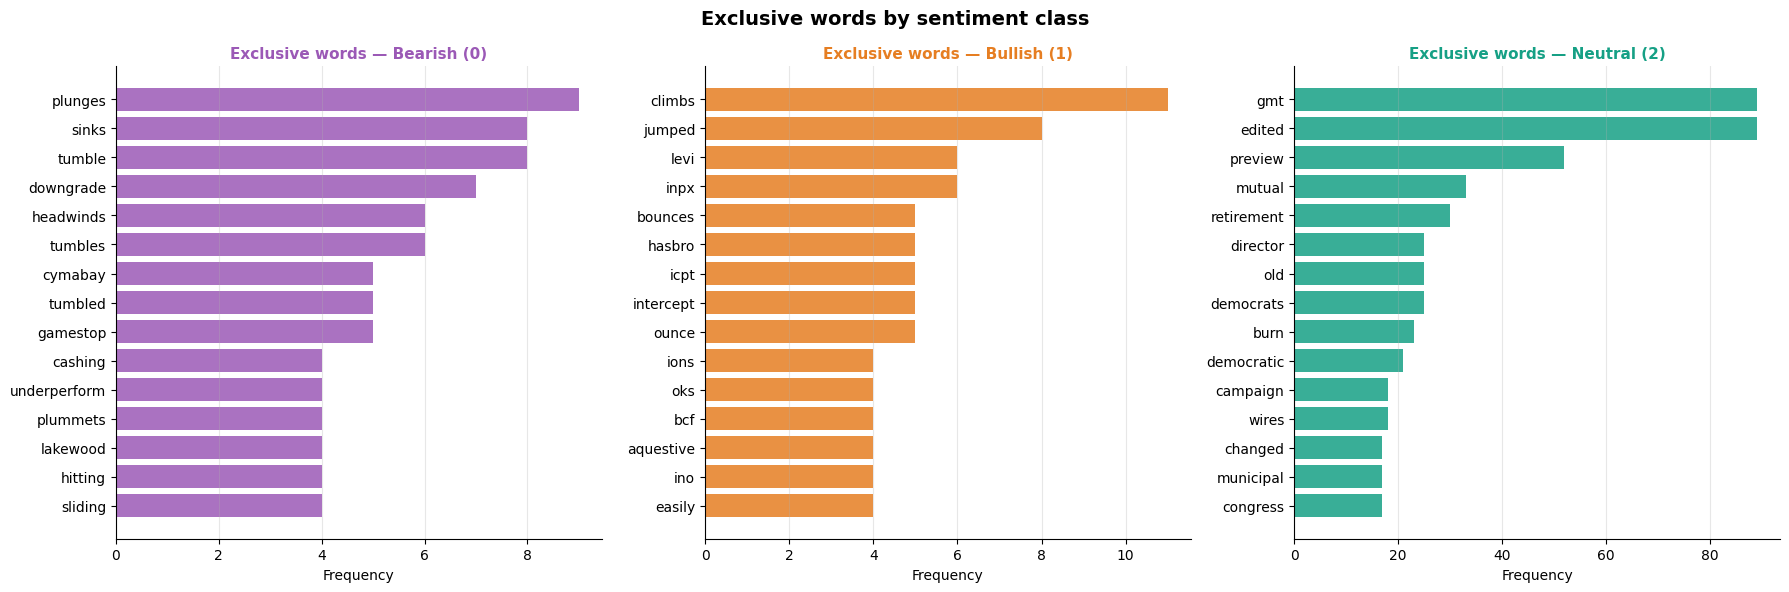

In [49]:
# Build vocabulary and word frequency counters for each sentiment class
vocab_per_class = {}
freq_per_class = {}

for lbl in [0, 1, 2]:
    class_tokens = []
    
    for text in df[df["label"] == lbl]["text"]:
        class_tokens.extend(tokenize_clean(text))
    
    vocab_per_class[lbl] = set(class_tokens)
    freq_per_class[lbl] = Counter(class_tokens)

# Alternative color palette for this visualization
EXCLUSIVE_COLORS = {
    0: "#9b59b6",  # Purple
    1: "#e67e22",  # Orange
    2: "#16a085"   # Teal
}

# Plot the top exclusive words for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Words that appear in the current class but not in the other classes
    other_classes_vocab = set().union(
        *[vocab_per_class[other_lbl] for other_lbl in [0, 1, 2] if other_lbl != lbl]
    )
    
    exclusive_words = vocab_per_class[lbl] - other_classes_vocab
    
    # Select the most frequent exclusive words
    top_exclusive_words = sorted(
        exclusive_words,
        key=lambda word: freq_per_class[lbl][word],
        reverse=True
    )[:15]
    
    counts = [freq_per_class[lbl][word] for word in top_exclusive_words]
    
    ax.barh(
        list(reversed(top_exclusive_words)),
        list(reversed(counts)),
        color=EXCLUSIVE_COLORS[lbl],
        edgecolor="none",
        alpha=0.85
    )
    
    ax.set_title(
        f"Exclusive words — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=EXCLUSIVE_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Exclusive words by sentiment class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Exclusive Words by Sentiment Class - Conclusion:**

The chart shows that some words appear exclusively within a single sentiment class. However, several of these words have relatively low frequencies, especially in the Bearish and Bullish classes, so they should be interpreted carefully. Overall, this analysis suggests that there are some class-specific vocabulary patterns.

## **3.6 Tweet-Specific Features**

This section examines tweet-specific features that may help characterize the structure of financial tweets, including hashtags, mentions, URLs, numeric expressions, and financial cashtags. These elements are extracted from the raw tweet text using regular expressions.

The visualization compares the distribution of these features across Bearish, Bullish, and Neutral tweets, helping identify whether some structural patterns are more common in specific sentiment classes.

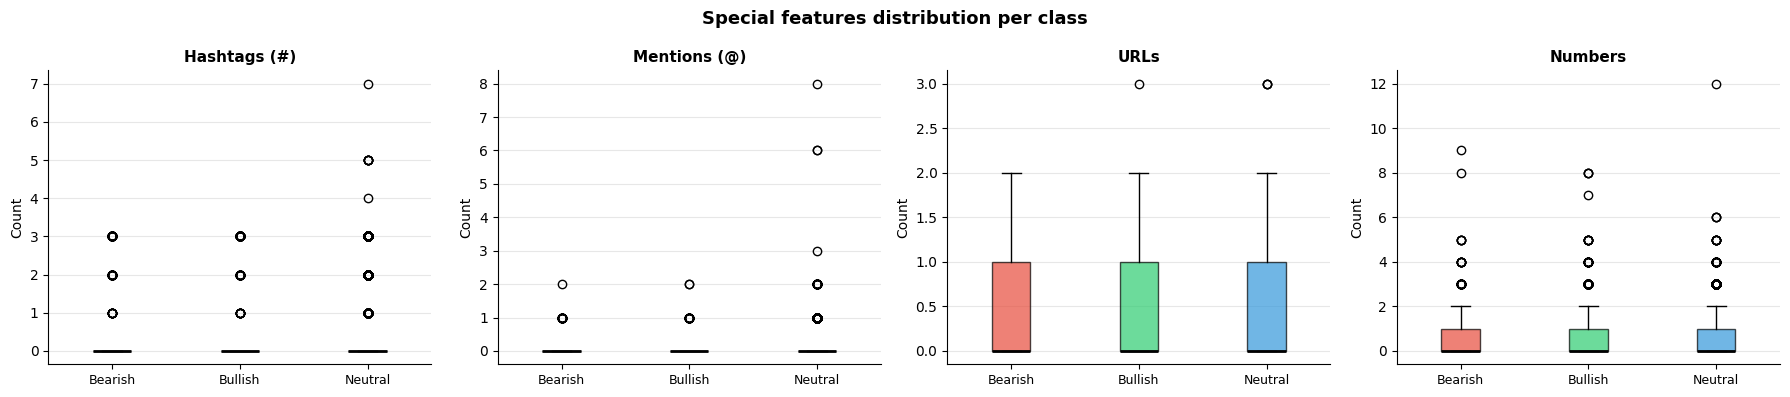

In [50]:
# ── Tweet-specific features: hashtags, mentions, URLs, numbers, cashtags ──────

# Count special elements in each tweet
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))  # e.g. $AAPL


# ── Distribution of tweet-specific features by class ─────────────────────────

features    = ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']
feat_labels = ['Hashtags (#)', 'Mentions (@)', 'URLs', 'Numbers']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# One boxplot per feature, showing the distribution across the 3 classes
for feat, flabel, ax in zip(features, feat_labels, axes):
    data_by_class = [df[df['label'] == lbl][feat].values for lbl in [0, 1, 2]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})

    # Color each box by class
    for patch, lbl in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)

    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Special features distribution per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Tweet-Specific Features - Conclusion:**

The boxplots show that most tweets contain very few tweet-specific elements. For hashtags, mentions, and numbers, the median is close to zero across all three sentiment classes, indicating that these elements are not present in most tweets. However, some outliers are visible, especially in the Neutral class, where a few tweets contain several hashtags, mentions, or numbers.

URLs appear with a slightly more consistent pattern, but their distribution is still very similar across Bearish, Bullish, and Neutral tweets. This suggests that URLs are common structural elements in financial tweets, but they do not seem to provide a clear distinction between sentiment classes.

Overall, these tweet-specific features help characterize the structure of the corpus, but they are unlikely to be strong predictors of sentiment on their own. Therefore, they mainly support preprocessing decisions, such as removing URLs and mentions, handling hashtags, and treating numeric expressions consistently.

## **3.7 Hashtags and Cashtags Analysis**

This analysis identifies the most common hashtags and financial cashtags within each sentiment class. This helps assess whether these tweet-specific elements contain useful information for distinguishing Bearish, Bullish, and Neutral tweets.

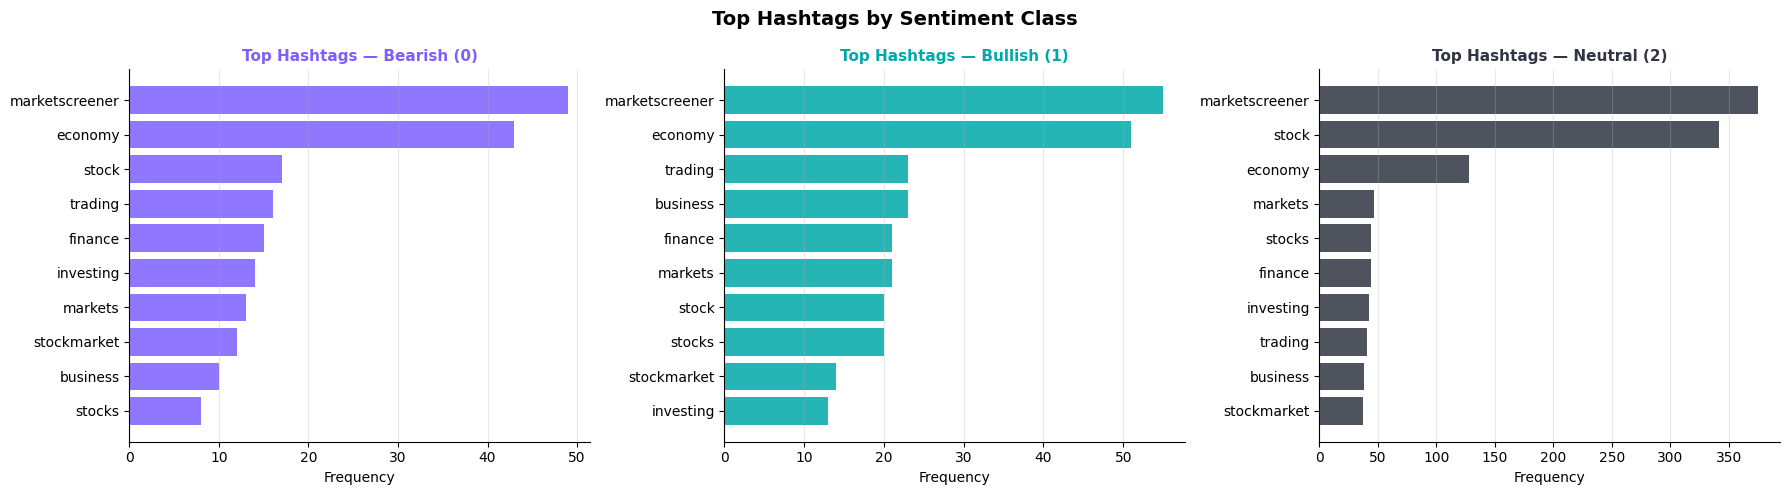

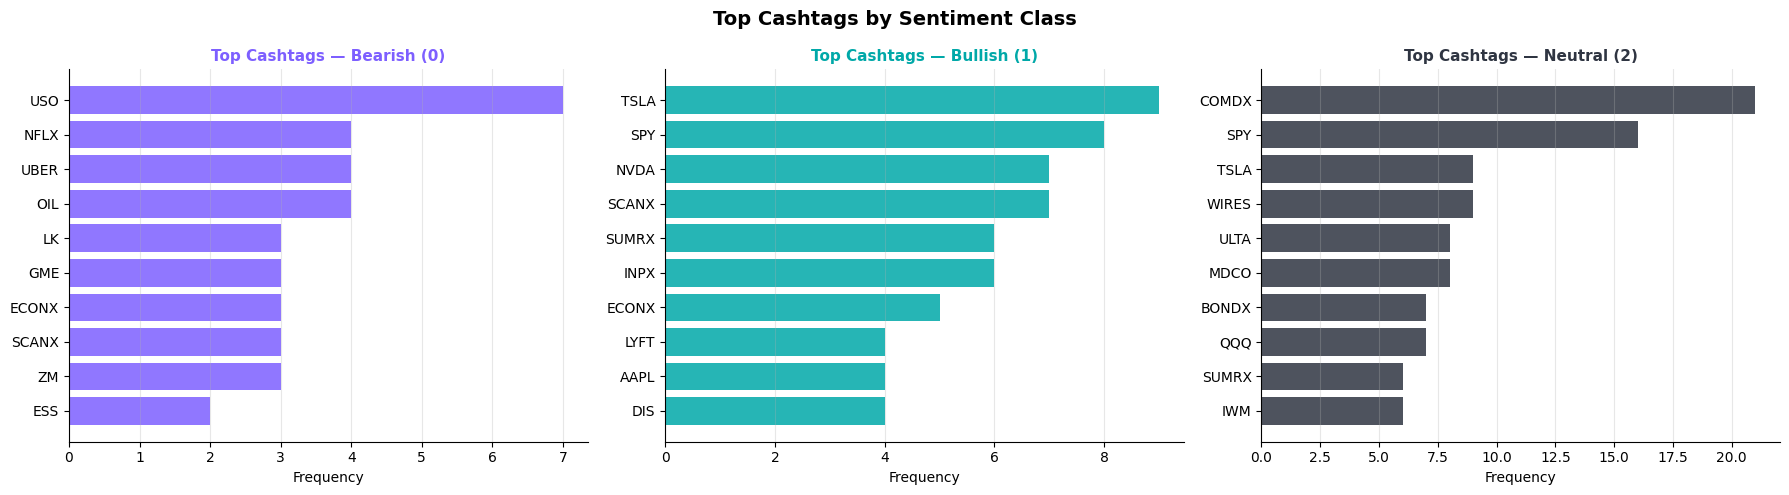

In [51]:
# Alternative color palette for class-based hashtag and cashtag visualizations
TOKEN_COLORS = {
    0: "#7d5fff",  # Violet
    1: "#00a8a8",  # Teal
    2: "#2f3542"   # Charcoal
}


# Plot top hashtags by sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lbl, ax in zip([0, 1, 2], axes):
    hashtags_class = []
    
    for txt in df[df["label"] == lbl]["text"]:
        hashtags_class.extend(re.findall(r"#(\w+)", str(txt).lower()))
    
    top_hashtags_class = Counter(hashtags_class).most_common(10)
    
    if top_hashtags_class:
        words, counts = zip(*top_hashtags_class)
        
        ax.barh(
            list(reversed(words)),
            list(reversed(counts)),
            color=TOKEN_COLORS[lbl],
            edgecolor="none",
            alpha=0.85
        )
    
    ax.set_title(
        f"Top Hashtags — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=TOKEN_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top Hashtags by Sentiment Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# Plot top cashtags by sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lbl, ax in zip([0, 1, 2], axes):
    cashtags_class = []
    
    for txt in df[df["label"] == lbl]["text"]:
        cashtags_class.extend(re.findall(r"\$([A-Za-z]{1,5})", str(txt).upper()))
    
    top_cashtags_class = Counter(cashtags_class).most_common(10)
    
    if top_cashtags_class:
        words, counts = zip(*top_cashtags_class)
        
        ax.barh(
            list(reversed(words)),
            list(reversed(counts)),
            color=TOKEN_COLORS[lbl],
            edgecolor="none",
            alpha=0.85
        )
    
    ax.set_title(
        f"Top Cashtags — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=TOKEN_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top Cashtags by Sentiment Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Hashtags and Cashtags Analysis - Conclusion:**

The hashtag analysis shows that the most frequent hashtags are very similar across the three sentiment classes, mainly representing broad financial topics such as markets, stocks, economy, and trading. Since they do not clearly distinguish sentiment classes, we decided to remove hashtags during preprocessing to reduce noise.

Cashtags, on the other hand, indicate that a financial asset or company is being mentioned. However, the sentiment associated with a specific ticker may depend on the time period of the tweet. For example, the same company could be associated with positive sentiment in one market period and negative sentiment in another. Since the temporal context of the tweets is not available, we decided to replace cashtags with a common placeholder token (`ticker`). This preserves the information that a financial asset was mentioned while reducing the risk of the model learning time-specific associations with individual companies or stock symbols.

### **N-gram Analysis by Class**

This analysis identifies the most frequent two-word and three-word expressions within each sentiment class. N-grams are useful because they capture short financial expressions that may carry more meaning than isolated words. 

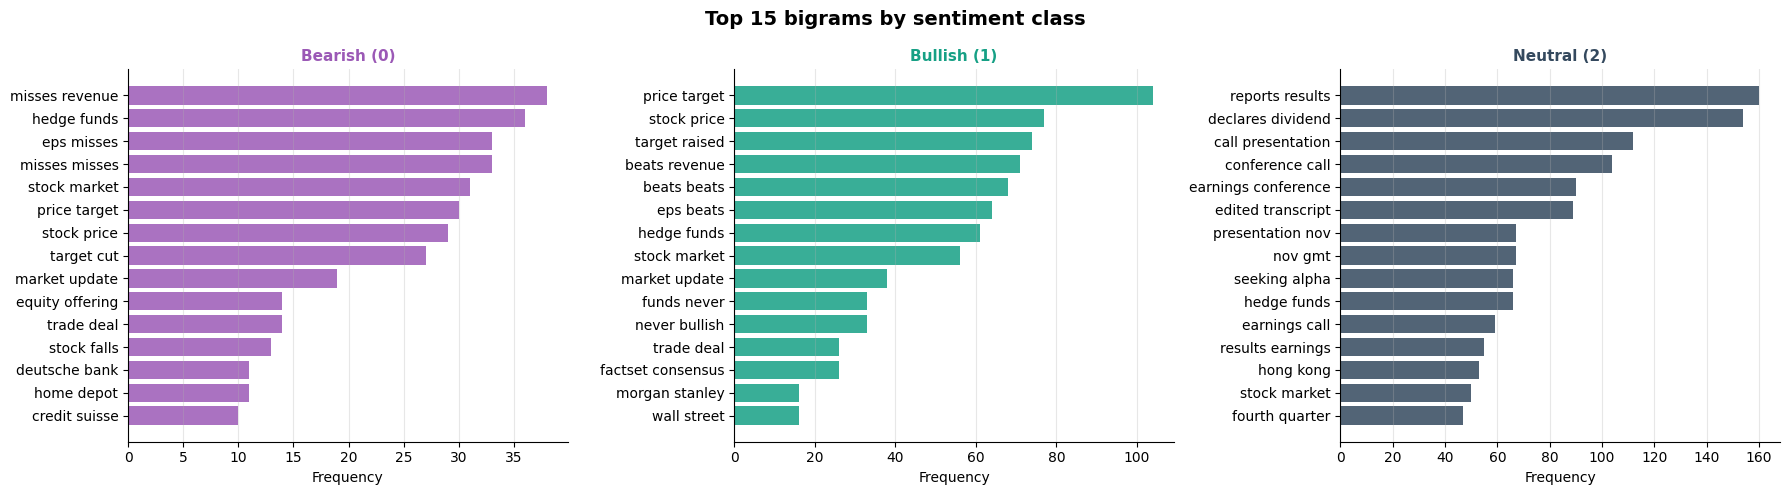

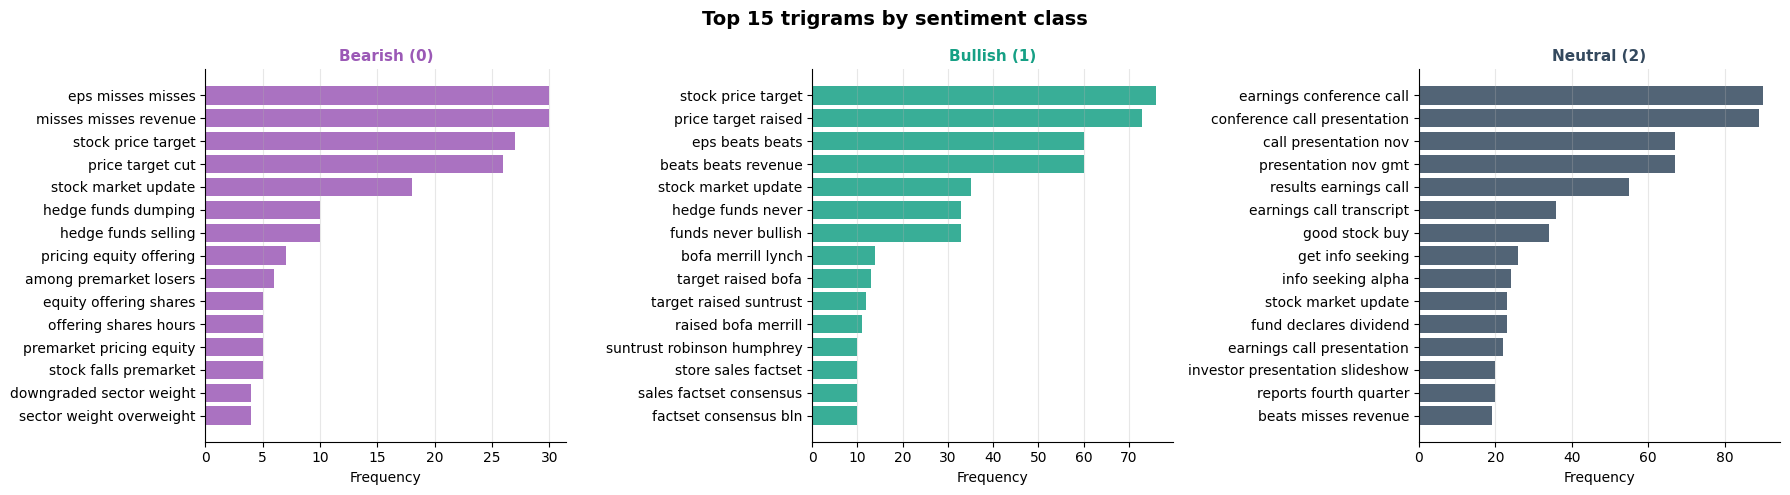

In [52]:
from nltk.util import ngrams

def get_ngrams(texts, n=2):
    """Extract n-grams from a collection of texts using the exploratory cleaning function."""
    all_ngrams = []
    
    for text in texts:
        tokens = tokenize_clean(text)
        all_ngrams.extend([" ".join(group) for group in ngrams(tokens, n)])
    
    return Counter(all_ngrams)


# Alternative color palette for the n-gram visualizations
NGRAM_COLORS = {
    0: "#9b59b6",  # Purple
    1: "#16a085",  # Teal
    2: "#34495e"   # Dark blue-gray
}

# Plot the top 15 bigrams and trigrams for each sentiment class
for n, ngram_name in [(2, "bigrams"), (3, "trigrams")]:
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for lbl, ax in zip([0, 1, 2], axes):
        ngrams_counter = get_ngrams(df[df["label"] == lbl]["text"], n=n)
        top_ngrams = ngrams_counter.most_common(15)
        
        if top_ngrams:
            words, counts = zip(*top_ngrams)
            
            ax.barh(
                list(reversed(words)),
                list(reversed(counts)),
                color=NGRAM_COLORS[lbl],
                edgecolor="none",
                alpha=0.85
            )
        
        ax.set_title(
            CLASS_NAMES[lbl],
            fontsize=11,
            fontweight="bold",
            color=NGRAM_COLORS[lbl]
        )
        
        ax.set_xlabel("Frequency")
        ax.grid(axis="x", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle(f"Top 15 {ngram_name} by sentiment class", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

**N-gram Analysis by Class - Conclusion:**

The n-gram analysis shows that short word combinations capture relevant financial and market-related patterns across the three sentiment classes. In the Bearish class, expressions such as “misses revenue”, “eps misses”, “target cut”, “stock falls”, and “eps misses misses” are associated with negative company performance or downward market movements. In the Bullish class, expressions such as “price target”, “target raised”, “beats revenue”, “eps beats”, and “price target raised” reflect positive expectations, analyst upgrades, or better-than-expected results.

Neutral tweets are more associated with reporting and corporate-event expressions, such as “reports results”, “declares dividend”, “conference call”, “earnings conference call”, and “call presentation nov”. These expressions are useful because they show that the Neutral class is often characterized by factual or event-based language, rather than directional market sentiment.

Overall, the comparison between bigrams and trigrams suggests that bigrams provide a good balance between context and generalization. While trigrams add more detail, some of them are more specific or repetitive, which may increase sparsity. Therefore, these results support testing TF-IDF with `ngram_range=(1,2)` in the feature engineering stage, as it captures useful short expressions without making the feature space too sparse.

**O QUE FIZ:**

-HÁ IMPORTS NO CODIGO ESPALHADOS MAS DPS ORGANIZAMOS ISSO NO FIM;

-JÁ TIREI AQUELA CENA DE GUARDAR AS IMAGENS DOS PLOTS DESTE CODIGO/NOTEBOOK;

-OS GRÁFICOS COM A ANÁLISE DO TOP HASHTAGS E TOP CASHTAGS FORAM POSTOS JUNTOS E TIRÁMOS O GRÁFICO DO "GLOBAL HASHTAGS" E DO "GLOBAL CASHTAGS" PQ N ACRESCENTAVA NADA (COSME NÓS DISCUTIMOS ISTO ONTEM);

-TIRÁMOS O CO-OCCURENCE HEATMAP PQ A ÚNICA COISA QUE NOS AJUDAVA ERA PARA DECIDIR `ngram_range=(1,2)` E ISSO JÁ TEMOS O BIGRAMS E TRIGRAMS (ISTO FOI UMA DECISÃO MUTUA NO GRUPO);

-NA ANÁLISE DO TWEET-LENGHT TIREI AQUELE HISTOGRAMA E DEIXEI SÓ OS BOXPLOTS PQ DOS DOIS ERA O QUE FAZIA MAIS SENTIDO E O QUE DAVA PARA TIRAR MAIS CONCLUSÕES (COSME NÓS DISCUTIMOS ISTO ONTEM);

-TIREI TDS OS PRINTS QUE MOSTRAVAM O MM QUE AS VISUALIZAÇÕES, OU SEJA, CONTAGENS;

-TIREI EMOJIS TMB QUE ESTAVAM NÓS CÓDIGOS QUE MEXI;

-ESTES CÓDIGOS ESTÃO TDS EM INGLÊS JÁ.


**NO QUE EU N MEXI AINDA:**

-2.12 LEXICAL DISPERSION

-2.15 Exploration Summary & Conclusions

-2.10 TWEETS WITH LITTLE CONTENT AFTER CLEANING

-SPECIAL CHARACTERS (+ − ! ? < >)

-EMOJI ANALYSIS

-Mention (@) Analysis

-Hashtag (#) Deep-Dive

-Uppercase Analysis

-Financial Sentiment Words